# Baseline inference — predict lesion type on new images

Load a trained **EfficientNetV2-B0** checkpoint and run predictions on paths you provide (single file or a folder of images).

## Data splits (training script)

The baseline trainer (`src/train_baseline_efficientnet.py`) uses **only two splits**:

- **Train** — used for optimization  
- **Validation** — used for monitoring and metrics (`val_split`, default 20%)

There is **no separate test set** in the current script. If you need a held-out **test** set for final reporting, add a three-way split (train / val / test) or reserve a test fraction and save `test_indices` in the checkpoint the same way as `val_indices`.

**Classes (3):** benign, malignant, non-neoplastic

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from baseline_metrics import LESION_CLASS_NAMES
from data_process import NUM_LESION_TYPES
from train_baseline_efficientnet import EfficientNetV2Baseline, get_device, IMAGENET_MEAN, IMAGENET_STD

/opt/anaconda3/envs/gan/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Checkpoint path

Set `CHECKPOINT` to `checkpoint.pt` from `outputs/baseline_efficientnet/<run>/`, or leave `None` to use the latest run.

In [4]:
CHECKPOINT = None  # e.g. ROOT / "outputs/baseline_efficientnet/20260130_120000/checkpoint.pt"

if CHECKPOINT is None:
    base = ROOT / "outputs" / "baseline_efficientnet"
    runs = sorted(base.glob("*/checkpoint.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not runs:
        raise FileNotFoundError(f"No checkpoint under {base}. Train the baseline first.")
    CHECKPOINT = runs[0]

CHECKPOINT = Path(CHECKPOINT)
print("Checkpoint:", CHECKPOINT)

Checkpoint: /Users/hoangnamtran/Desktop/Code/SkinLesionBiasReduction/outputs/baseline_efficientnet/20260330_195351/checkpoint.pt


In [5]:
device = get_device(None)
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
args_ns = ckpt.get("args", {})
pretrained = bool(args_ns.get("pretrained", True)) and not bool(args_ns.get("no_pretrained", False))
dropout = float(args_ns.get("dropout", 0.3))
image_size = int(args_ns.get("image_size", 64))

model = EfficientNetV2Baseline(
    num_classes=NUM_LESION_TYPES,
    pretrained=pretrained,
    dropout=dropout,
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

val_tf = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print("image_size:", image_size, "| device:", device)

image_size: 64 | device: mps


## 2. Predict helper

Returns predicted class, confidence, and probabilities for all three classes.

In [6]:
@torch.no_grad()
def predict_path(image_path: Path):
    """Load one image (RGB), run model, return dict with prediction and probs."""
    image_path = Path(image_path)
    img = Image.open(image_path).convert("RGB")
    x = val_tf(img).unsqueeze(0).to(device)
    logits = model(x)
    probs = F.softmax(logits, dim=1).squeeze(0).cpu().numpy()
    pred_idx = int(probs.argmax())
    return {
        "path": str(image_path),
        "predicted_class": LESION_CLASS_NAMES[pred_idx],
        "confidence": float(probs[pred_idx]),
        "probabilities": {LESION_CLASS_NAMES[i]: float(probs[i]) for i in range(len(LESION_CLASS_NAMES))},
    }


def predict_paths(paths):
    """List of paths or a directory (jpg/jpeg/png)."""
    paths = list(paths)
    if len(paths) == 1 and Path(paths[0]).is_dir():
        folder = Path(paths[0])
        exts = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
        paths = sorted(p for p in folder.iterdir() if p.suffix.lower() in exts)
    return [predict_path(p) for p in paths]

## 3. Run inference + show images

- **`IMAGE_PATHS`**: list of file paths, **or** one **folder** (all `.jpg`/`.jpeg`/`.png` in that folder).
- **True labels** come from `dataset/fitzpatrick17k_cleaned.csv` by matching the file stem to `md5hash`. Images not in the CSV show `true: (not in CSV)`.

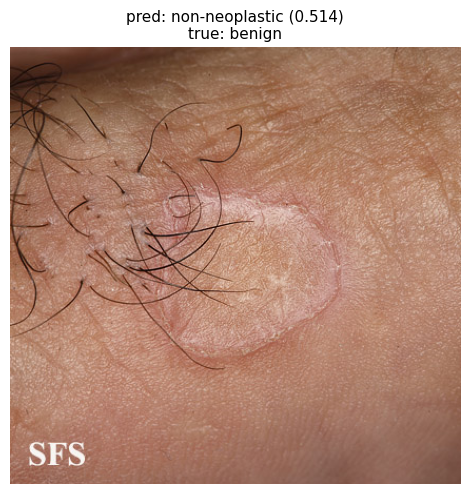

ffe62c609421e3adaa69ee1751dd6a37.jpg -> non-neoplastic (0.514) | true: benign
  {'benign': 0.2241908609867096, 'malignant': 0.26164302229881287, 'non-neoplastic': 0.5141661167144775}


In [8]:
# Ground-truth lesion label from dataset CSV (filename must match md5hash in CSV)
CSV_FOR_LABELS = ROOT / "dataset" / "fitzpatrick17k_cleaned.csv"
_label_df = pd.read_csv(CSV_FOR_LABELS)
_label_by_hash = _label_df.set_index("md5hash")["three_partition_label"].to_dict()


def true_label_for_path(image_path: Path):
    stem = Path(image_path).stem
    return _label_by_hash.get(stem)  # None if not in CSV (e.g. external test image)

# One or more files, OR one folder (all .jpg/.jpeg/.png in that folder — slow if huge):
IMAGE_PATHS = [ROOT / "dataset/images" / "ffe62c609421e3adaa69ee1751dd6a37.jpg"]
# IMAGE_PATHS = [ROOT / "dataset/images"]  # entire folder — only for small folders

IMAGE_PATHS = [Path(p) for p in IMAGE_PATHS]
results = predict_paths(IMAGE_PATHS)

for r in results[:20]:
    p = Path(r["path"])
    true_lbl = true_label_for_path(p)
    img = Image.open(p).convert("RGB")

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.axis("off")
    true_str = true_lbl if true_lbl is not None else "(not in CSV)"
    title = f"pred: {r['predicted_class']} ({r['confidence']:.3f})\ntrue: {true_str}"
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()

    print(p.name, "->", r["predicted_class"], f"({r['confidence']:.3f})", "| true:", true_lbl)
    print(" ", r["probabilities"])

if len(results) > 20:
    print(f"... and {len(results) - 20} more")